<a href="https://colab.research.google.com/github/Rogerio-mack/AD_solucao/blob/main/Aula_06_avaliacao_solucao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade Avaliativa - Laboratório de Análise de Dados**

In [ ]:
#@markdown Nome **COMPLETO** e RA

Nome = 'Pixinguinha' #@param {type:"string"}
RA = '22.000921-3' #@param {type:"string"}
#@markdown

suffix_file = RA.replace('.','')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

path = 'https://github.com/Rogerio-mack/work/raw/main/data/'

#@markdown Salve o seu notebook com **Ex1_02D_\<seu_nome\>.ipynb**

#@markdown Execute esta célula para prosseguir.

# Q1. Correlação

Empregue o dataset penguins abaixo.

1. Obtenha, para a espécie mais frequente de pinguins, a correlação do atributo mais correlacionado, para machos e fêmeas, ao peso do pinguim.

2. Com base nisso, construa um gráfico como abaixo.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

df = sns.load_dataset('penguins')
display(df.head())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [ ]:
df.species.value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [ ]:
specie = "Adelie"

selecao = (df.species == specie) & (df.sex == "Male")
corr_male = df[ selecao ][ df.select_dtypes(include='number').columns ].corr().loc[:,'body_mass_g'].sort_values(ascending=False)
display(corr_male)

selecao = (df.species == specie) & (df.sex == "Female")
corr_female = df[ selecao ][ df.select_dtypes(include='number').columns ].corr().loc[:,'body_mass_g'].sort_values(ascending=False)
display(corr_female)

,body_mass_g
body_mass_g,1.000000
flipper_length_mm,0.360434
bill_length_mm,0.220370
bill_depth_mm,0.159558


,body_mass_g
body_mass_g,1.000000
bill_depth_mm,0.396937
flipper_length_mm,0.262930
bill_length_mm,0.170095


## Q1. Seu gráfico

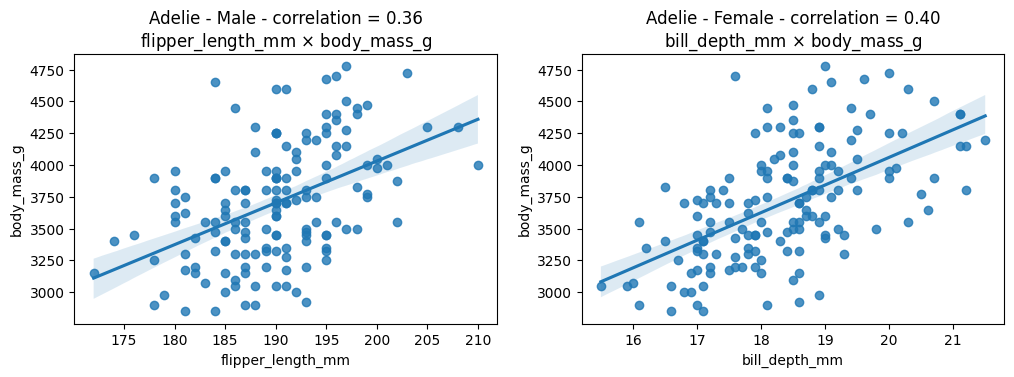

In [ ]:
# Male
x = 'flipper_length_mm'
y = 'body_mass_g'
sex = "Male"
selecao = (df.species == specie) & (df.sex == sex)

plt.figure(figsize=(12,3.5))

plt.subplot(1,2,1)
sns.regplot(data=df[ df.species == specie ], x=x, y=y)
plt.title(f'{specie} - {sex} - correlation = {df[ selecao ][ x ].corr(df[ selecao ][ y ]):.2f}\n{x} $\\times$ {y}')
# plt.title(f'{'Imperador'} - {'Male'} - correlation = {0.99:.2f}\n{"bill_depth_mm"} $\\times$ {y}')
plt.xlabel(x)
plt.ylabel(y)
# plt.xlabel('bill_depth_mm')

# Female
x = 'bill_depth_mm'
y = 'body_mass_g'
sex = "Female"
selecao = (df.species == specie) & (df.sex == sex)

plt.subplot(1,2,2)
sns.regplot(data=df[ df.species == specie ], x=x, y=y)
plt.title(f'{specie} - {sex} - correlation = {df[ selecao ][ x ].corr(df[ selecao ][ y ]):.2f}\n{x} $\\times$ {y}')
# plt.title(f'{'Imperador'} - {'Female'} - correlation = {0.01:.2f}\n{"bill_length_mm"} $\\times$ {y}')
plt.xlabel(x)
plt.ylabel(y)
# plt.xlabel('bill_length_mm')

plt.show()


In [ ]:
print(f'{'Imperador'} - {'Male'} - correlation = {0.99:.2f}\n{"bill_depth_mm"} x {y}')
print()
print(f'{'Imperador'} - {'Female'} - correlation = {0.01:.2f}\n{"bill_length_mm"} x {y}')


Imperador - Male - correlation = 0.99
bill_depth_mm x body_mass_g

Imperador - Female - correlation = 0.01
bill_length_mm x body_mass_g


# Q2. Intervalo de Confiança

Em um experimento de física uma partícula tem sua posição $(X,Y)$ regida por uma distribuição normal, de parâmetros média e desvio padrão, conforme a figura abaixo. Qual a posição esperada de ser encontrada a partícula em 95% dos casos? Isto é o intervalo de valores de $X$ e $Y$ em 95% dos casos.

In [ ]:
from scipy.stats import norm

mu_x, sigma_x = 2.8, 0.5
mu_y, sigma_y = 4.5, 0.35
x = norm.rvs(loc=mu_x, scale=sigma_x, size=1000)
y = norm.rvs(loc=mu_y, scale=sigma_y, size=1000)

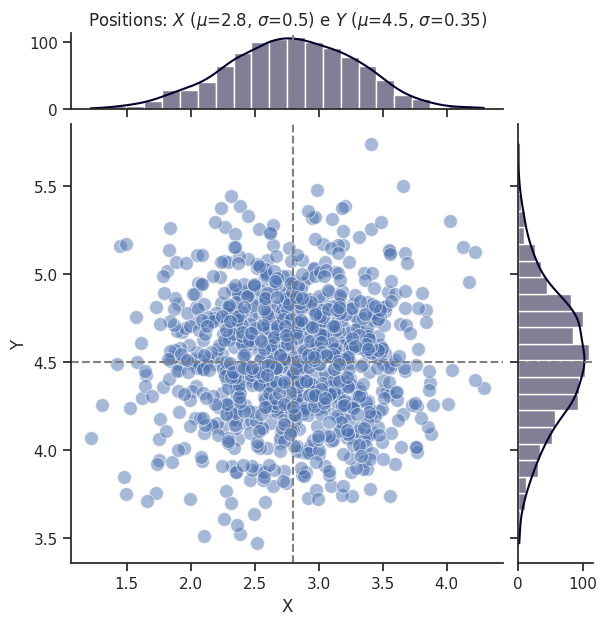

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")

g = sns.JointGrid(x=x, y=y, marginal_ticks=True)
g.plot_joint(sns.scatterplot, s=100, alpha=.5)
g.plot_marginals(sns.histplot, kde=True, color="#03012d")
g.refline(x=mu_x, y=mu_y)
g.set_axis_labels('X', 'Y')

# Adicionando título e rótulos ao plot marginal X (superior)
g.ax_marg_x.set_title(f'Positions: $X$ ($\\mu$={mu_x}, $\\sigma$={sigma_x}) e $Y$ ($\\mu$={mu_y}, $\\sigma$={sigma_y})')

plt.show()

In [ ]:
print(f'IC(x,95%) = [ {norm.ppf(0.025, loc=mu_x, scale=sigma_x):.3f}, {norm.ppf(1- 0.025, loc=mu_x, scale=sigma_x):.3f} ]')
print(f'IC(y,95%) = [ {norm.ppf(0.025, loc=mu_y, scale=sigma_y):.3f}, {norm.ppf(1- 0.025, loc=mu_y, scale=sigma_y):.3f} ]')


IC(x,95%) = [ 1.820, 3.780 ]
IC(y,95%) = [ 3.814, 5.186 ]


## Q2. Resposta

Modelo de resposta.

In [ ]:
print(f'IC(x,95%) = [ {norm.ppf(0.025, loc=1, scale=sigma_x):.3f}, {norm.ppf(1- 0.025, loc=1, scale=sigma_x):.3f} ]')
print(f'IC(y,95%) = [ {norm.ppf(0.025, loc=2, scale=sigma_y):.3f}, {norm.ppf(1- 0.025, loc=2, scale=sigma_y):.3f} ]')

IC(x,95%) = [ 0.020, 1.980 ]
IC(y,95%) = [ 1.314, 2.686 ]


# Q3. Distribuição de sobrevivência ou falha

A função de densidade de probabilidade de `Weibull_min` é:

 $$f(x,c) = c x^{c-1} exp(-x^{c})$$

para $x > 0$, $c> 0$. Ela pode ser empregada para modelar problemas de *sobrevivência* ou de *tempo de falha*, como o tempo de falha ($x$) de uma peça, dispositivo ou maquinário. $c$ é um parâmetro de forma da curva. O exemplo abaixo mostra a distribuição do tempo de falha de uma lâmpada com tempo médio de duração de 1000h acesa para diferentes valores de $c$.

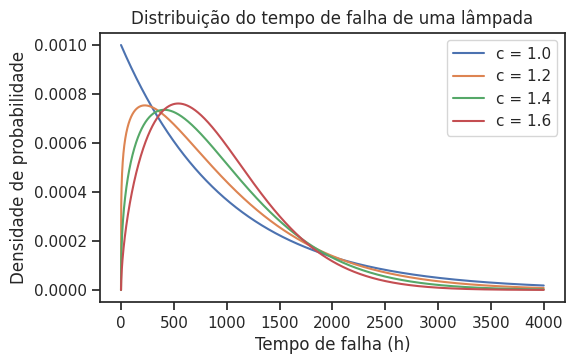

In [ ]:
from scipy.stats import weibull_min
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

x = np.arange(0,4*1000,1)

plt.figure(figsize=(6,3.5))
for c in np.arange(1,1.8,0.2):
  pdf = weibull_min.pdf(x, c=c, scale=1000)
  sns.lineplot(x=x,y=pdf,label=f'c = {np.round(c,2)}')

plt.title('Distribuição do tempo de falha de uma lâmpada')
plt.xlabel('Tempo de falha (h)')
plt.ylabel('Densidade de probabilidade')
plt.legend()
plt.show()


A sobrevida de uma GPU é regida por uma distribuição de `Weibull_min` de parâmetro $c=1.05$ e tempo médio de falha de 60 meses segundo o fabricante. Sua empresa acaba de adquirir 1000 GPUs. O preço de cada GPU é USD 3,000.00

>  a. Qual o orçamento que a empresa precisa reservar para troca de GPU nos primeiros 2 anos?

>  b. Qual o orçamento que a empresa precisa reservar para trocas no 3o ano?


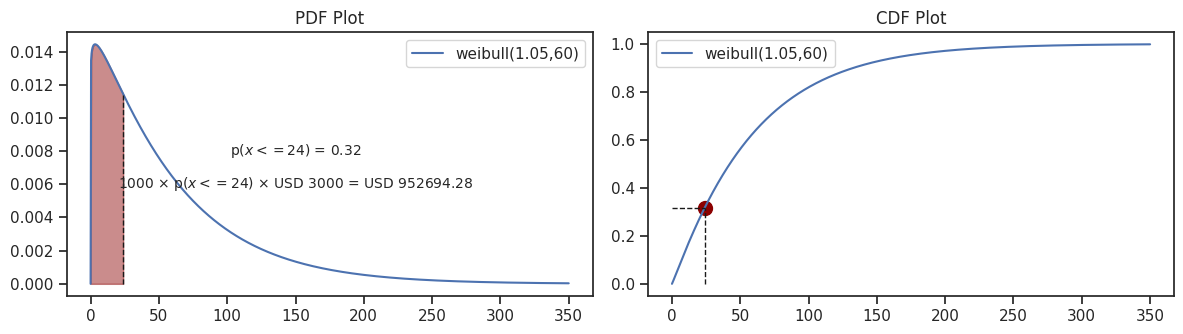

In [ ]:
from scipy.stats import weibull_min
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

np.random.seed(1)
fig, ax = plt.subplots(1,2,figsize=(12,3.5))

x = np.linspace(0,350,1000) # ou
# x = stats.weibull_min.rvs(c=1.05, scale=60, size=1000)

pdf_values = weibull_min.pdf(x, c=1.05, scale=60)
cdfs_values = weibull_min.cdf(x, c=1.05, scale=60)

sns.lineplot(x=x, y=pdf_values, label='weibull(1.05,60)',ax=ax[0])
ax[0].vlines(24,0,weibull_min.pdf(24, c=1.05, scale=60),linestyle='--',color='k',lw=1)
ax[0].fill_between(x, pdf_values, where=(x < 24), color='darkred', alpha=0.45)

p = weibull_min.cdf(24, c=1.05, scale=60)
ax[0].text(150,0.0080,f'p($x <= 24$) = {p:.2f}',ha='center',va='center',fontsize=10)

ax[0].text(150,0.0060,f'1000 $\\times$ p($x <= 24$) $\\times$ USD 3000 = USD {1000 * p * 3000:.2f}',ha='center',va='center',fontsize=10)


ax[0].set_title('PDF Plot')
ax[0].legend()

sns.lineplot(x=x, y=cdfs_values, label='weibull(1.05,60)',ax=ax[1])
ax[1].vlines(24,0,weibull_min.cdf(24, c=1.05, scale=60),linestyle='--',color='k',lw=1)
ax[1].hlines(weibull_min.cdf(24, c=1.05, scale=60),0,24,linestyle='--',color='k',lw=1)
ax[1].scatter(24, weibull_min.cdf(24, c=1.05, scale=60), color='darkred', s=100)
ax[1].set_title('CDF Plot')
ax[1].legend()

plt.tight_layout()
plt.show()

## Q3.1 Valor

## Q3.2 Valor

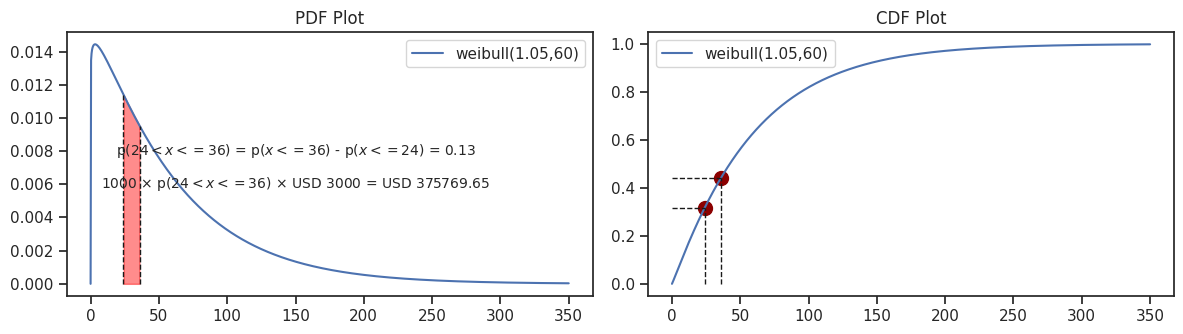

In [ ]:
from scipy.stats import weibull_min
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

np.random.seed(1)
fig, ax = plt.subplots(1,2,figsize=(12,3.5))

x = np.linspace(0,350,1000) # ou
# x = stats.weibull_min.rvs(c=1.05, scale=60, size=1000)

pdf_values = weibull_min.pdf(x, c=1.05, scale=60)
cdfs_values = weibull_min.cdf(x, c=1.05, scale=60)

sns.lineplot(x=x, y=pdf_values, label='weibull(1.05,60)',ax=ax[0])
ax[0].vlines(24,0,weibull_min.pdf(24, c=1.05, scale=60),linestyle='--',color='k',lw=1)
ax[0].vlines(36,0,weibull_min.pdf(36, c=1.05, scale=60),linestyle='--',color='k',lw=1)
ax[0].fill_between(x, pdf_values, where=((x > 24) & (x < 36)), color='red', alpha=0.45)

p = weibull_min.cdf(36, c=1.05, scale=60) - weibull_min.cdf(24, c=1.05, scale=60)
ax[0].text(150,0.0080,f'p($24 < x <= 36$) = p($x <= 36$) - p($x <= 24$) = {p:.2f}',ha='center',va='center',fontsize=10)

ax[0].text(150,0.0060,f'1000 $\\times$ p($24 < x <= 36$) $\\times$ USD 3000 = USD {1000 * p * 3000:.2f}',ha='center',va='center',fontsize=10)


ax[0].set_title('PDF Plot')
ax[0].legend()

sns.lineplot(x=x, y=cdfs_values, label='weibull(1.05,60)',ax=ax[1])
ax[1].vlines(24,0,weibull_min.cdf(24, c=1.05, scale=60),linestyle='--',color='k',lw=1)
ax[1].vlines(36,0,weibull_min.cdf(36, c=1.05, scale=60),linestyle='--',color='k',lw=1)
ax[1].hlines(weibull_min.cdf(24, c=1.05, scale=60),0,24,linestyle='--',color='k',lw=1)
ax[1].hlines(weibull_min.cdf(36, c=1.05, scale=60),0,36,linestyle='--',color='k',lw=1)
ax[1].scatter(24, weibull_min.cdf(24, c=1.05, scale=60), color='darkred', s=100)
ax[1].scatter(36, weibull_min.cdf(36, c=1.05, scale=60), color='darkred', s=100)
ax[1].set_title('CDF Plot')
ax[1].legend()

plt.tight_layout()
plt.show()